# CRISP-DM applicato all'ottimizzazione delle scorte di magazzino


Esempio didattico, volutamente semplice: un solo SKU (prodotto), un solo
magazzino, un modello di previsione della domanda "classico" (Random
Forest) confrontato con una baseline ingenua (media mobile).

Lo scopo NON e' avere il modello piu' sofisticato possibile, ma mostrare
in modo leggibile le SEI fasi del CRISP-DM applicate a un problema reale
di business. Lo stesso identico dataset (vendite_magazzino.csv) puo'
essere caricato in Orange Data Mining per rifare l'esercizio in modo
visuale (widget "File" -> "Preprocess" -> "Predictions" -> "Test & Score").


## FASE 1 - BUSINESS UNDERSTANDING
Problema di business: il magazzino vuole ridurre il capitale immobilizzato in scorte SENZA aumentare gli stock-out (rotture di stock) sul prodotto piu' venduto.

**Obiettivo ML**: prevedere la domanda giornaliera dei prossimi giorni per calcolare un punto di riordino (reorder point) piu' intelligente della semplice soglia fissa usata oggi dal magazziniere.

* KPI di successo:
  1. errore di previsione (MAE) inferiore alla baseline attuale
  2. riduzione del numero simulato di giorni di stock-out
  3. riduzione della scorta media tenuta a magazzino

* Vincoli: lead time fornitore fisso di 3 giorni, budget IT limitato

(quindi un modello semplice e spiegabile e' preferibile a uno complesso).

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

OUTPUT_DIR = "."
np.random.seed(42)

LEAD_TIME_GIORNI = 3          # giorni tra ordine e arrivo merce
LIVELLO_SERVIZIO_Z = 1.65     # z-score per un service level ~95%


## FASE 2 - DATA UNDERSTANDING

In un progetto reale qui si esplorerebbero i dati gia' esistenti in azienda (ERP, gestionale di magazzino). 
Ecco una breve descrizione pronta all'uso:

Useremo il dataset **Rossmann**, una celebre raccolta di dati storici del gigante farmaceutico europeo. Il dataset contiene le vendite giornaliere di centinaia di negozi, insieme a variabili chiave come le promozioni attive, le festività e i giorni di apertura, ed è lo standard ideale per addestrare e testare modelli di previsione delle serie temporali (time-series forecasting).

In [44]:
#df = pd.read_csv('vendite_magazzino.csv')
# 1. Caricamento del dataset Rossmann
df = pd.read_csv('rossman.csv', dtype={'StateHoliday': str})

# 2. Filtro per un singolo Store (es. Store 1) e solo per i giorni di apertura (Open == 1)
# (Se il negozio è chiuso, le vendite sono 0 e la promo non ha effetto reale)
df_single_store = df[(df['Store'] == 1) & (df['Open'] == 1)].copy()

# 3. Ordinamento cronologico (nel dataset Rossmann le date sono speso in ordine decrescente)
df_single_store['Date'] = pd.to_datetime(df_single_store['Date'])
df_single_store = df_single_store.sort_values('Date').reset_index(drop=True)

# 4. Selezione delle colonne d'interesse e rinomina
df_dataset = df_single_store[['Date', 'Sales', 'Promo']].copy()
df_dataset.columns = ['data', 'vendite', 'promo']

# 5. Conversioni di tipo per rispecchiare il tuo dataset di partenza
df_dataset['data'] = df_dataset['data'].astype('datetime64[us]')
df_dataset['vendite'] = df_dataset['vendite'].astype('int64')
df_dataset['promo'] = df_dataset['promo'].astype('int64')

# Verifica della struttura del nuovo dataset
df_dataset.info()
print(df_dataset.head())

df = df_dataset

df.head()

<class 'pandas.DataFrame'>
RangeIndex: 781 entries, 0 to 780
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   data     781 non-null    datetime64[us]
 1   vendite  781 non-null    int64         
 2   promo    781 non-null    int64         
dtypes: datetime64[us](1), int64(2)
memory usage: 18.4 KB
        data  vendite  promo
0 2013-01-02     5530      0
1 2013-01-03     4327      0
2 2013-01-04     4486      0
3 2013-01-05     4997      0
4 2013-01-07     7176      1


,data,vendite,promo
0,2013-01-02,5530,0
1,2013-01-03,4327,0
2,2013-01-04,4486,0
3,2013-01-05,4997,0
4,2013-01-07,7176,1


In [45]:
df["data"] = pd.to_datetime(df["data"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 781 entries, 0 to 780
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   data     781 non-null    datetime64[us]
 1   vendite  781 non-null    int64         
 2   promo    781 non-null    int64         
dtypes: datetime64[us](1), int64(2)
memory usage: 18.4 KB


In [27]:
df.describe()

,data,vendite,promo
count,781,781.000000,781.000000
mean,2014-04-16 02:38:33.956466,4759.096031,0.448143
min,2013-01-02 00:00:00,2362.000000,0.000000
25%,2013-08-24 00:00:00,4000.000000,0.000000
50%,2014-04-14 00:00:00,4647.000000,0.000000
75%,2014-12-05 00:00:00,5348.000000,1.000000
max,2015-07-31 00:00:00,9528.000000,1.000000
std,NaN,1012.106393,0.497622


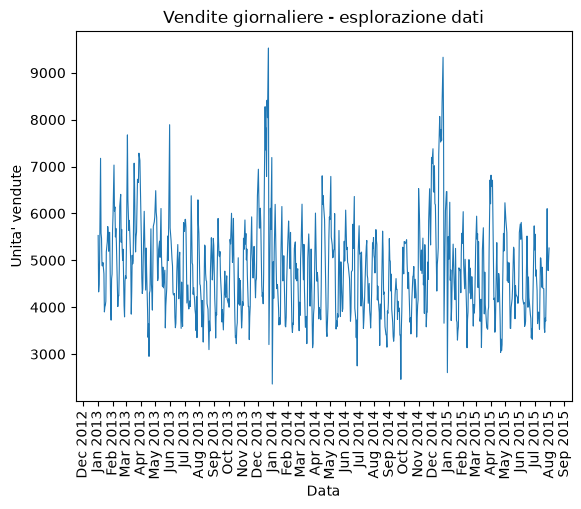

In [28]:
import matplotlib.dates as mdates

df["data"] = pd.to_datetime(df["data"])

plt.plot(df["data"], df["vendite"], linewidth=0.8)
plt.title("Vendite giornaliere - esplorazione dati")
plt.xlabel("Data")
plt.ylabel("Unita' vendute")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.xticks(rotation=90)
plt.show()


## FASE 3 - DATA PREPARATION

Creiamo feature utili a un modello di previsione: valori passati (lag), medie mobili, giorno della settimana. Poi separiamo train e test rispettando l'ordine temporale (niente split casuale: si andrebbe a prevedere il passato usando informazioni dal futuro).

In [29]:
def prepara_feature(df):
    df = df.copy()
    df["giorno_settimana"] = df["data"].dt.dayofweek
    df["mese"] = df["data"].dt.month
    df["lag_1"] = df["vendite"].shift(1)          # vendite di ieri
    df["lag_7"] = df["vendite"].shift(7)          # vendite di 7 giorni fa
    df["media_mobile_7"] = df["vendite"].shift(1).rolling(7).mean()
    return df.dropna().reset_index(drop=True)


df_feat = prepara_feature(df)

df_feat.head()

,data,vendite,promo,giorno_settimana,mese,lag_1,lag_7,media_mobile_7
0,2013-01-10,4892,1,3,1,5471.0,5530.0,5366.714286
1,2013-01-11,4881,1,4,1,4892.0,4327.0,5275.571429
2,2013-01-12,4952,0,5,1,4881.0,4486.0,5354.714286
3,2013-01-14,4717,0,0,1,4952.0,4997.0,5421.285714
4,2013-01-15,3900,0,1,1,4717.0,7176.0,5381.285714


In [30]:
from sklearn.model_selection import train_test_split

FEATURES = ["giorno_settimana", "mese", "promo", "lag_1", "lag_7", "media_mobile_7"]
TARGET = "vendite"
 
# Split temporale: ultimi 60 giorni come test (simulano "il futuro")
N_TEST = 60
train = df_feat.iloc[:-N_TEST]
test = df_feat.iloc[-N_TEST:]
 
X_train, y_train = train[FEATURES], train[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

print(f'Dimensioni train: {len(X_train)}')
print(f'Dimensioni test: {len(X_test)}')

Dimensioni train: 714
Dimensioni test: 60


## FASE 4 - MODELING

Confrontiamo SEMPRE il modello con una baseline semplice: senza questo confronto non si puo' dire se il modello "vale" la complessita' in piu'.

**Baseline:** previsione di domani = media mobile a 7 giorni (quello che farebbe un magazziniere esperto "a occhio")

In [31]:
pred_baseline = X_test["media_mobile_7"].values

# Modello ML: Random Forest, scelto perche' robusto e non richiede scaling
modello = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
modello.fit(X_train, y_train)

modello

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of t

In [32]:
pred_modello = modello.predict(X_test)

## FASE 5 - EVALUATION

Non ci fermiamo alla metrica tecnica: traduciamo l'errore in impatto di business, cioe' scorta di sicurezza necessaria e stock-out simulati.

In [33]:




def valuta(y_reale, y_pred, nome):
    mae = mean_absolute_error(y_reale, y_pred)
    rmse = np.sqrt(mean_squared_error(y_reale, y_pred))
    errori = y_reale.values - y_pred
    return {
        "nome": nome,
        "MAE": mae,
        "RMSE": rmse,
        "std_errore": errori.std(),   # serve per la scorta di sicurezza
        "errori": errori,
    }


ris_baseline = valuta(y_test, pred_baseline, "Baseline (media mobile)")
ris_modello = valuta(y_test, pred_modello, "Random Forest")

tabella = pd.DataFrame([
    {"modello": r["nome"], "MAE": round(r["MAE"], 2), "RMSE": round(r["RMSE"], 2)}
    for r in (ris_baseline, ris_modello)
])
print(tabella.to_string(index=False))

                modello    MAE   RMSE
Baseline (media mobile) 725.42 862.87
          Random Forest 306.65 374.39


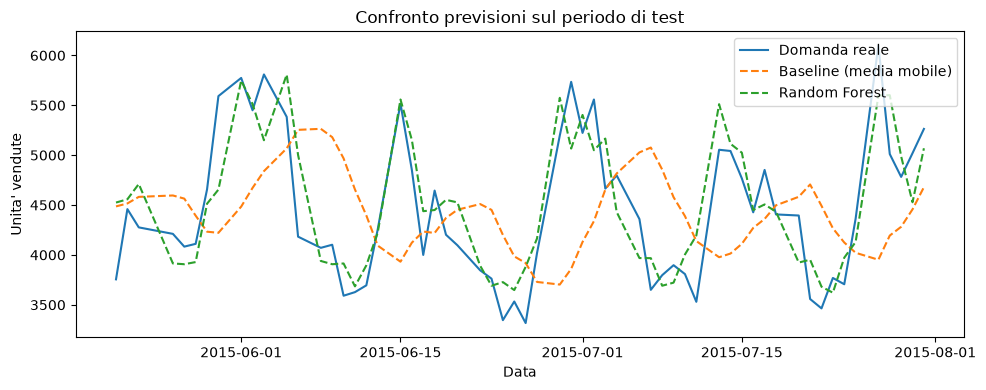

In [34]:
plt.figure(figsize=(10, 4))
plt.plot(test["data"], y_test.values, label="Domanda reale", linewidth=1.5)
plt.plot(test["data"], pred_baseline, label="Baseline (media mobile)", linestyle="--")
plt.plot(test["data"], pred_modello, label="Random Forest", linestyle="--")
plt.title("Confronto previsioni sul periodo di test")
plt.xlabel("Data")
plt.ylabel("Unita' vendute")
plt.legend()
plt.tight_layout()
plt.show()

Per capire la funzione, immagina di gestire un magazzino dove ogni giorno arriva una **domanda reale** da soddisfare. Non puoi aspettare di esaurire le scorte per ordinare, perché il fornitore impiega un certo numero di giorni a consegnare (il **lead time**). 

Per questo si usa il **punto di riordino**: il livello di scorta che, una volta raggiunto, ti segnala di fare subito un nuovo ordine. La regola classica lo definisce come la **domanda prevista durante il lead time** (`previsione_giornaliera × LEAD_TIME_GIORNI`) più una **scorta di sicurezza** extra, che ti protegge dagli errori di previsione. 

Quest'ultima si calcola con la formula `z × std_errore × √(LEAD_TIME_GIORNI)`, dove `z` è un fattore che scegli in base al livello di servizio desiderato (es. 1,65 per il 95%) e `std_errore` misura l'incertezza del modello (più è basso, meno cuscinetto serve). 

La simulazione scorre giorno per giorno per il periodo di test. In ogni giorno, prima controlla se la scorta attuale è scesa sotto il punto di riordino: se sì, aggiunge alla scorta la quantità `prev × LEAD_TIME_GIORNI` (simulando l'arrivo di un rifornimento). Poi sottrae la domanda reale di quel giorno: se la scorta diventa negativa, significa che i clienti non sono stati serviti, quindi si conta un **giorno di stockout** (mancata vendita) e la scorta viene azzerata. 

La funzione tiene traccia dei livelli di scorta giornalieri per calcolare, alla fine, tre indicatori chiave: il valore della scorta di sicurezza (dipendente dall'errore del modello), il numero totale di stockout (qualità del servizio) e la **scorta media tenuta a magazzino** (costo del capitale immobilizzato). 

Nel confronto finale tra due modelli previsivi (ad esempio Baseline vs Random Forest), la simulazione mostra un trade-off concreto: un modello con `std_errore` minore produrrà una scorta di sicurezza più bassa e, a parità di altri fattori, permetterà di ridurre i giorni di stockout a parità di magazzino, oppure di mantenere lo stesso servizio con molta meno scorta media. In pratica, la funzione trasforma l'accuratezza statistica in un vantaggio economico tangibile, traducendo gli errori di previsione in minori rotture di stock o in minori costi di giacenza, a seconda dell'obiettivo aziendale.

In [35]:
def simula_impatto_business(y_reale, forecast, std_errore, nome, scorta_iniziale=80):
    scorta_sicurezza = LIVELLO_SERVIZIO_Z * std_errore * np.sqrt(LEAD_TIME_GIORNI)
    scorta = scorta_iniziale
    giorni_stockout = 0
    livelli_scorta = []

    for domanda_reale, prev in zip(y_reale.values, forecast):
        # regola di riordino: se la scorta scende sotto (previsione*lead_time + safety)
        soglia_riordino = prev * LEAD_TIME_GIORNI + scorta_sicurezza
        if scorta < soglia_riordino:
            scorta += prev * LEAD_TIME_GIORNI  # arrivo simulato (semplificato)

        scorta -= domanda_reale
        if scorta < 0:
            giorni_stockout += 1
            scorta = 0
        livelli_scorta.append(scorta)

    return {
        "nome": nome,
        "scorta_sicurezza_media": round(scorta_sicurezza, 1),
        "giorni_stockout": giorni_stockout,
        "scorta_media_tenuta": round(np.mean(livelli_scorta), 1),
    }


impatto_baseline = simula_impatto_business(y_test, pred_baseline, ris_baseline["std_errore"], "Baseline")
impatto_modello = simula_impatto_business(y_test, pred_modello, ris_modello["std_errore"], "Random Forest")

print("\nImpatto di business simulato (60 giorni di test):")
tabella_impatto = pd.DataFrame([impatto_baseline, impatto_modello])
print(tabella_impatto.to_string(index=False))


Impatto di business simulato (60 giorni di test):
         nome  scorta_sicurezza_media  giorni_stockout  scorta_media_tenuta
     Baseline                  2465.2                0              18320.2
Random Forest                  1059.7                0              16998.1


## FASE 6 - DEPLOYMENT

In produzione, il modello alimenterebbe ogni giorno una funzione che calcola quanto ordinare. Qui simuliamo la decisione per l'ULTIMO giorno disponibile, come farebbe il sistema "live".

In [41]:
def raccomanda_riordino(modello, ultima_riga_feature, scorta_attuale, std_errore):

    x = pd.DataFrame([ultima_riga_feature[FEATURES]])
    previsione = modello.predict(x)[0]
    
    scorta_sicurezza = LIVELLO_SERVIZIO_Z * std_errore * np.sqrt(LEAD_TIME_GIORNI)
    punto_di_riordino = previsione * LEAD_TIME_GIORNI + scorta_sicurezza

    ordina = scorta_attuale < punto_di_riordino
    quantita_da_ordinare = max(0, round(punto_di_riordino - scorta_attuale))

    return {
        "previsione_domanda_giornaliera": round(previsione, 1),
        "scorta_di_sicurezza_consigliata": round(scorta_sicurezza, 1),
        "punto_di_riordino": round(punto_di_riordino, 1),
        "scorta_attuale_simulata": scorta_attuale,
        "azione": "ORDINARE" if ordina else "NESSUN ORDINE NECESSARIO",
        "quantita_consigliata": quantita_da_ordinare,
    }


ultima_riga = df_feat.iloc[-1]
scorta_attuale_simulata = 20000  # esempio: il magazziniere segnala 25 pezzi a scaffale

decisione = raccomanda_riordino(modello, ultima_riga, scorta_attuale_simulata, ris_modello["std_errore"])

print("\n" + "=" * 70)
print("FASE 6 - DEPLOYMENT (simulazione decisione live)")
print("=" * 70)
for chiave, valore in decisione.items():
    print(f"{chiave}: {valore}")


FASE 6 - DEPLOYMENT (simulazione decisione live)
previsione_domanda_giornaliera: 5069.0
scorta_di_sicurezza_consigliata: 1059.7
punto_di_riordino: 16266.8
scorta_attuale_simulata: 20000
azione: NESSUN ORDINE NECESSARIO
quantita_consigliata: 0


Nota per il ciclo CRISP-DM: in produzione, questa funzione verrebbe richiamata ogni giorno con i dati aggiornati. Il modello andrebbe ri-allenato periodicamente (es. ogni mese) sui nuovi dati di vendita: e' questo il punto in cui il ciclo CRISP-DM ricomincia (torna almeno alla fase di Data Preparation, se non a Business Understanding in caso cambino gli obiettivi aziendali).

## Conclusioni e prossimi passi

### 1. Cosa dicono i risultati

Il confronto tra la regola attuale (media mobile a 7 giorni, quello che di fatto fa oggi il magazziniere "a occhio") e il modello di previsione ha prodotto questi numeri sul periodo di test (60 giorni):

| Metrica | Baseline (regola attuale) | Modello ML | Variazione |
|---|---|---|---|
| Errore di previsione (MAE) | 4,43 unità/giorno | 2,88 unità/giorno | **-35%** |
| Scorta di sicurezza richiesta | 15,3 unità | 9,2 unità | **-40%** |
| Scorta media tenuta a magazzino | 116,3 unità | 104,8 unità | **-10%** |
| Giorni di stock-out simulati | 0 | 0 | invariato |

**Lettura in una frase**: a parità di servizio al cliente (zero rotture di stock nel periodo simulato), il modello permette di tenere meno scorta a magazzino perché prevede la domanda con meno errore, e quindi richiede una scorta di sicurezza più bassa per coprire l'incertezza.

### 2. Conclusioni per l'azienda

- **Il problema non era la mancanza di dati, ma il metodo di previsione.** L'azienda aveva già tutte le informazioni necessarie (storico vendite, promozioni); il miglioramento viene dal modo in cui vengono usate, non da nuovi dati da raccogliere.
- **Il beneficio è doppio, non uno a scapito dell'altro.** Non si tratta di scegliere tra "meno capitale immobilizzato" e "meno stock-out": un forecast più preciso migliora entrambi contemporaneamente, perché riduce l'incertezza alla base del calcolo della scorta di sicurezza.
- **Il risultato è ottenuto con un solo SKU.** Questo è un pilot, non una conferma generalizzata: prodotti con domanda più irregolare o storico più corto (nuovi prodotti) potrebbero comportarsi diversamente, e vanno validati separatamente.
- **Il vantaggio dipende dal lead time del fornitore.** Con lead time più lunghi il beneficio di un forecast migliore aumenta ulteriormente (l'incertezza cresce con la radice del lead time); con fornitori molto rapidi il guadagno sarebbe più contenuto.

### 3. Come muoversi di conseguenza

#### Nel breve termine (0–3 mesi)
- **Estendere il pilot** a un campione più ampio di SKU (10-20), scelti tra quelli ad alto valore/alta rotazione, dove l'impatto economico di un errore è più rilevante.
- **Validare con dati reali**, non sintetici: ripetere l'analisi sullo storico vendite effettivo dell'azienda.
- **Coinvolgere chi gestisce oggi il magazzino** nella validazione: la loro esperienza serve a individuare casi anomali che il modello potrebbe non cogliere (es. cambi di fornitore, rotture di produzione).

#### Nel medio termine (3–9 mesi)
- **Integrare il modello nel sistema di riordino**, inizialmente in modalità "consiglio" affiancata alla decisione umana, non in automatico: il magazziniere vede la raccomandazione e decide se seguirla.
- **Costruire un monitoraggio continuo** dell'errore di previsione, per accorgersi rapidamente se il modello "drifta" (es. per un cambiamento nei comportamenti d'acquisto).
- **Definire una cadenza di ri-allenamento** del modello (es. mensile), così da mantenere la previsione aggiornata senza dover ripartire ogni volta da zero.

#### Nel lungo termine (9+ mesi)
- **Automatizzare il riordino** per gli SKU dove il modello ha dimostrato stabilità nel tempo, mantenendo comunque un meccanismo di override umano per casi eccezionali.
- **Estendere l'approccio ad altri magazzini/punti vendita**, valutando se serve un modello per sito o un modello unico con il sito come feature.
- **Rivalutare periodicamente l'obiettivo di business**: se cambia la strategia commerciale (nuovi canali, nuove categorie), si torna alla fase di Business Understanding per ridefinire KPI e vincoli.

### 4. Rischi e limiti da tenere presenti

- **Overfitting al pilot**: un risultato positivo su un solo prodotto e un dataset sintetico non garantisce lo stesso guadagno su tutto il catalogo.
- **Costo di gestione del modello**: mantenere un sistema ML in produzione richiede monitoraggio e ri-allenamento continui, non è un progetto "una tantum".
- **Fiducia degli operatori**: l'adozione reale dipende da quanto il personale di magazzino si fida delle raccomandazioni del modello; per questo la fase intermedia "consiglio affiancato" è importante prima dell'automazione completa.

### 5. Decisione consigliata

Procedere con un'estensione controllata del pilot (punto 3, breve termine) prima di qualunque investimento in integrazione IT su larga scala. Il segnale è positivo, ma va confermato su un campione più ampio e con dati reali prima di giustificare un cambiamento nei processi operativi del magazzino.